# Lab 4 – Intensity Transformations and Filtering: Spatial Domain

## Task 1: Thresholding

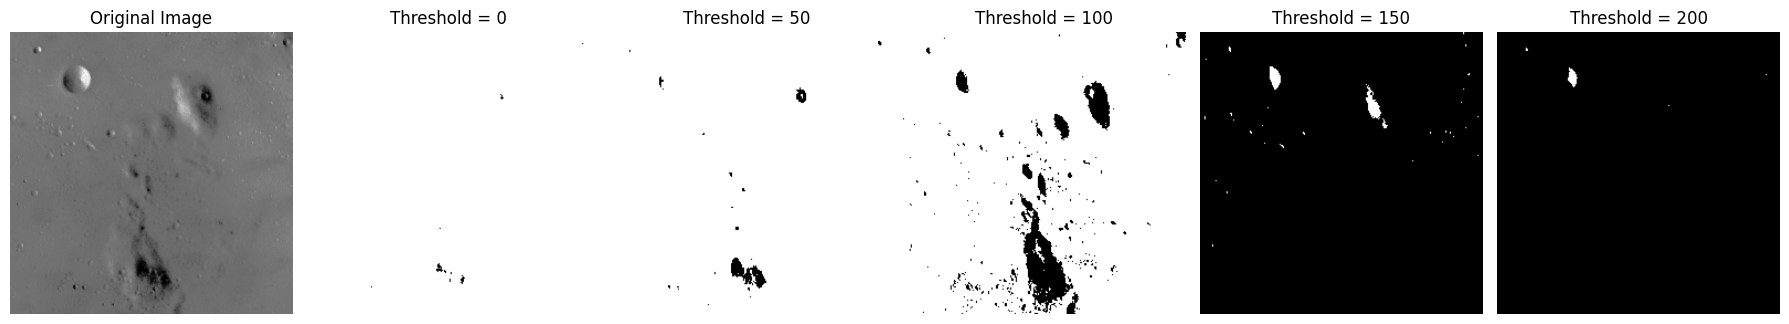

In [2]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
from skimage import data, img_as_float, exposure
from skimage.exposure import match_histograms

# Load the moon image as grayscale for thresholding demo
img = data.moon()

# Set the threshold values
threshold_values = [0, 50, 100, 150, 200]

fig, axes = plt.subplots(1, len(threshold_values) + 1, figsize=(18, 4))

# Display the original image
axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

# Apply thresholding with different threshold values
for i, threshold_value in enumerate(threshold_values):
    ret, thresh = cv2.threshold(img, threshold_value, 255, cv2.THRESH_BINARY)
    axes[i + 1].imshow(thresh, cmap='gray')
    axes[i + 1].set_title(f'Threshold = {threshold_value}')
    axes[i + 1].axis('off')

plt.tight_layout()
plt.show()

## Task 2: Histogram Processing – Contrast Stretching

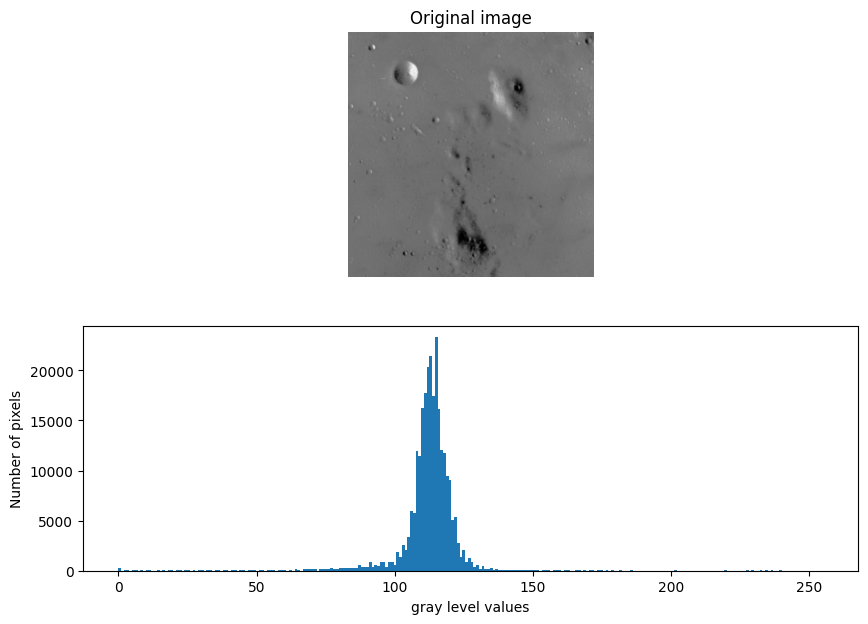

In [3]:
# Load moon image
img = data.moon()

# Contrast stretching using 2nd and 98th percentiles
p2, p98 = np.percentile(img, (2, 98))
img_rescale = exposure.rescale_intensity(img, in_range=(p2, p98))

# Display original image and histogram
fig = plt.figure(figsize=(10, 7))
fig.add_subplot(2, 1, 1)
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.title('Original image')
fig.add_subplot(2, 1, 2)
plt.hist(img.flat, bins=256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

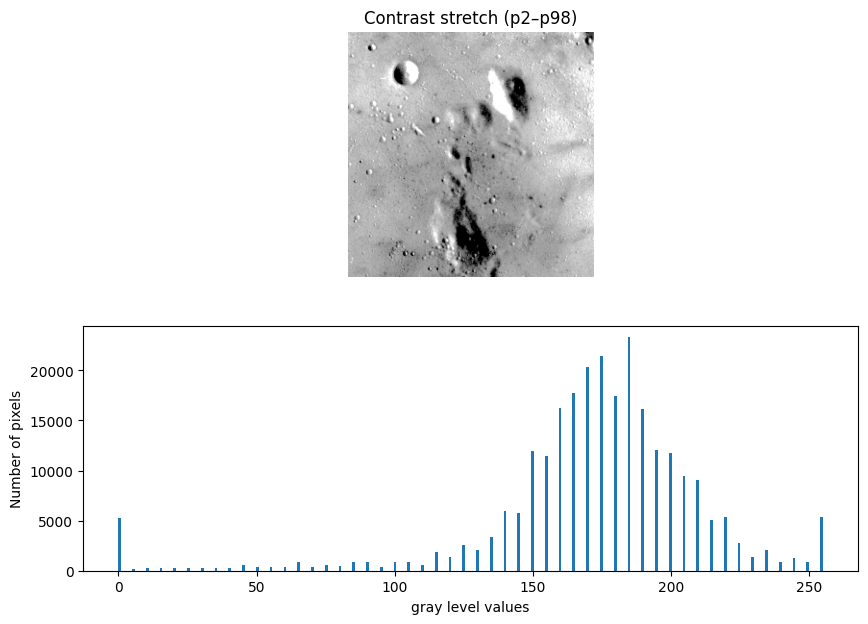

In [4]:
# Display contrast-stretched image and histogram
fig = plt.figure(figsize=(10, 7))
fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale, cmap='gray')
plt.axis('off')
plt.title('Contrast stretch (p2–p98)')
fig.add_subplot(2, 1, 2)
plt.hist(img_rescale.flat, bins=256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

---
## Assessment

### Assessment Task 1: Rescale intensity (3rd–80th percentiles)

3rd percentile: 87.0, 80th percentile: 118.0


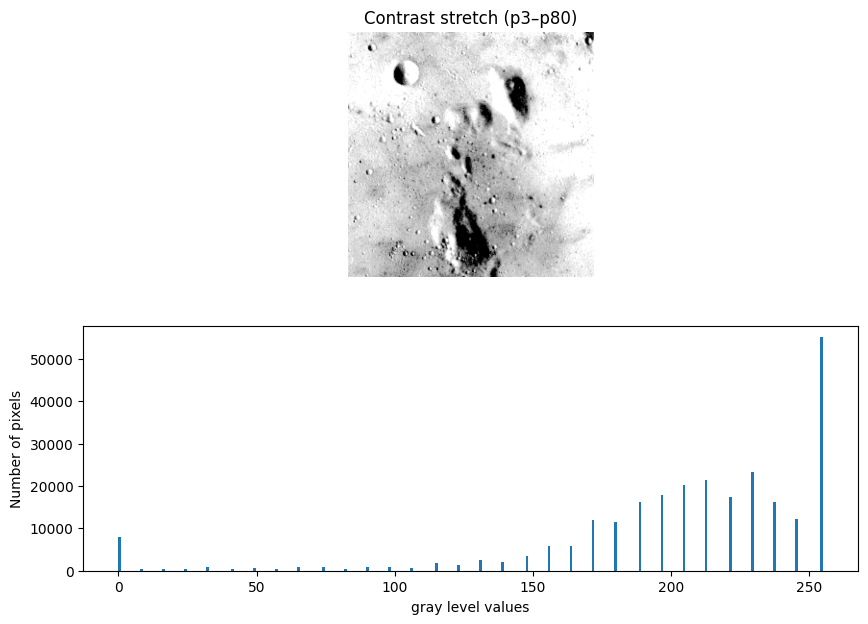

In [5]:
# Using the moon image, rescale intensity to 3rd–80th percentiles
img = data.moon()

p3, p80 = np.percentile(img, (3, 80))
img_rescale_3_80 = exposure.rescale_intensity(img, in_range=(p3, p80))

print(f'3rd percentile: {p3}, 80th percentile: {p80}')

# Display rescaled image and histogram
fig = plt.figure(figsize=(10, 7))
fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale_3_80, cmap='gray')
plt.axis('off')
plt.title('Contrast stretch (p3–p80)')
fig.add_subplot(2, 1, 2)
plt.hist(img_rescale_3_80.flat, bins=256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

### Assessment Task 2: Histogram Equalization

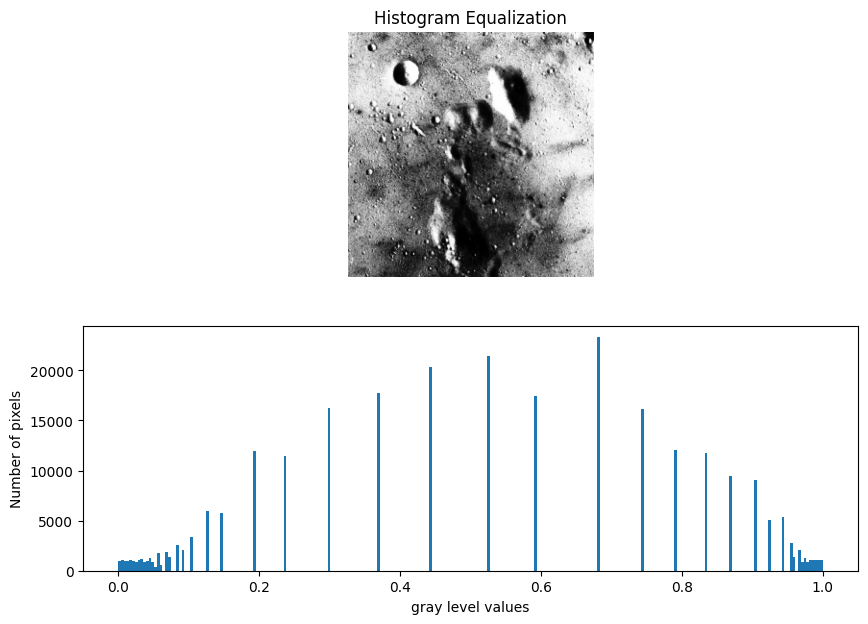

In [6]:
# Histogram equalization using exposure.equalize_hist
img = data.moon()
img_eq = exposure.equalize_hist(img)

# Display equalized image and histogram
fig = plt.figure(figsize=(10, 7))
fig.add_subplot(2, 1, 1)
plt.imshow(img_eq, cmap='gray')
plt.axis('off')
plt.title('Histogram Equalization')
fig.add_subplot(2, 1, 2)
plt.hist(img_eq.flat, bins=256, range=(0, 1))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

### Assessment Task 3: Histogram Matching

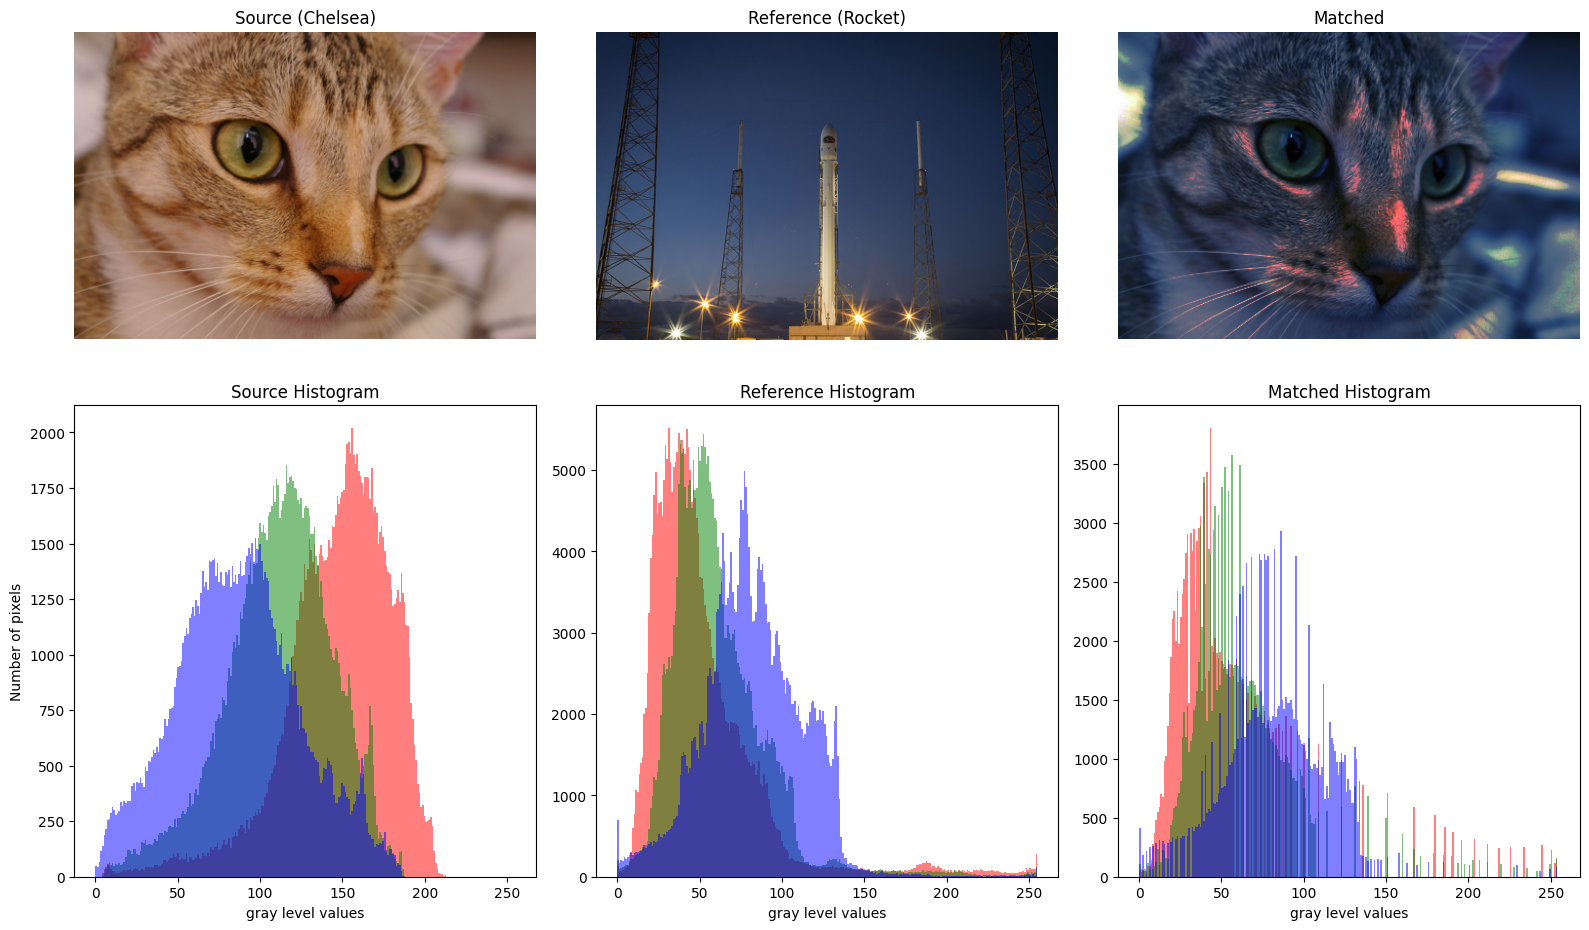

In [7]:
# Load reference (rocket) and source (chelsea) images
reference = data.rocket()
source = data.chelsea()

# Perform histogram matching
matched = match_histograms(source, reference, channel_axis=-1)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Row 1: Images
axes[0, 0].imshow(source)
axes[0, 0].set_title('Source (Chelsea)')
axes[0, 0].axis('off')

axes[0, 1].imshow(reference)
axes[0, 1].set_title('Reference (Rocket)')
axes[0, 1].axis('off')

axes[0, 2].imshow(matched.astype(np.uint8))
axes[0, 2].set_title('Matched')
axes[0, 2].axis('off')

# Row 2: Histograms for each image (all channels)
for c, color in enumerate(('red', 'green', 'blue')):
    axes[1, 0].hist(source[:, :, c].flat, bins=256, range=(0, 255), color=color, alpha=0.5)
    axes[1, 1].hist(reference[:, :, c].flat, bins=256, range=(0, 255), color=color, alpha=0.5)
    axes[1, 2].hist(matched[:, :, c].flat, bins=256, range=(0, 255), color=color, alpha=0.5)

axes[1, 0].set_title('Source Histogram')
axes[1, 0].set_xlabel('gray level values')
axes[1, 0].set_ylabel('Number of pixels')

axes[1, 1].set_title('Reference Histogram')
axes[1, 1].set_xlabel('gray level values')

axes[1, 2].set_title('Matched Histogram')
axes[1, 2].set_xlabel('gray level values')

plt.tight_layout()
plt.show()